## Trend Analysis of Stock Prices

This project performs **trend analysis** on historical stock price data and visualizes it using **color-coded line plots** to highlight positive and negative trends.

### Data Collection

- The script uses **Yahoo Finance** via `yfinance` to download historical price data for a given ticker (e.g., **SPY**).  
- The dataset contains daily prices over the past year, including **Open, High, Low, Close, and Volume**.

### Trend Metrics

Three types of trend indicators are computed over a **5-day rolling window**:

1. **Logarithmic Trend (`LogTrend`)**  
   - Computes the **rolling mean of logarithmic returns**
   - Positive values indicate upward movement; negative values indicate downward movement.

2. **Slope Trend (`SlopeTrend`)**  
   - Calculates the **slope of a linear fit** over the last 5 closing prices.  
   - A positive slope implies an upward trend; a negative slope indicates a downtrend.

3. **Count Trend (`CountTrend`)**  
   - Counts the number of **up days vs. down days** in the last 5 periods:  
     - Up day (`Close > Open`) → +1  
     - Down day (`Close ≤ Open`) → -1  
   - Sum of these values gives a simple momentum signal.

### Visualization

- Each trend is plotted with the **closing price line colored by trend direction**:
  - **Green** for positive trend
  - **Red** for negative trend
- This allows quick visual identification of **short-term trend changes**.

### Purpose

This project provides a **simple framework for trend analysis** in financial markets.  
It can be extended for:

- Developing **trading signals**
- Comparing different trend metrics
- Backtesting **momentum strategies**

In [86]:
import numpy as np
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [87]:
TICKER = "SPY"
INTERVAL = "1d"
PERIOD = "1y"

In [88]:
df = yf.download(TICKER, interval=INTERVAL, period=PERIOD)

/tmp/ipykernel_14059/2138203923.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(TICKER, interval=INTERVAL, period=PERIOD)
[*********************100%***********************]  1 of 1 completed


In [89]:
def log_trend(df):
  log_ret = np.log(df["Close"] / df["Close"].shift(1))
  trend = log_ret.rolling(5).mean()
  return trend

In [90]:
def slope_trend(df):
  def apply_slope(series):
    y = series.values
    x = np.arange(len(y))
    slope = np.polyfit(x, y, 1)[0]
    return slope
  
  trend = df["Close"].rolling(5).apply(apply_slope, raw=False)
  return trend

In [91]:
def count_trend(df):
  trend = (
    (df["Open"] < df["Close"])
    .astype(int)
    .replace({0: -1})
    .rolling(5)
    .sum()
  )
  return trend

In [92]:
df["LogTrend"] = log_trend(df)
df["SlopeTrend"] = slope_trend(df)
df["CountTrend"] = count_trend(df)

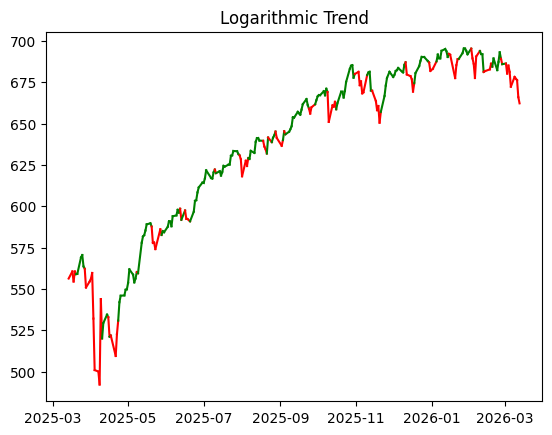

In [93]:
for i in range(1, len(df)):
  c = "g" if df["LogTrend"].iloc[i] > 0 else "r"
  plt.plot(
    df.index[i-1:i+1],
    df["Close"].iloc[i-1:i+1],
    color=c
  )

plt.title("Logarithmic Trend")
plt.show()

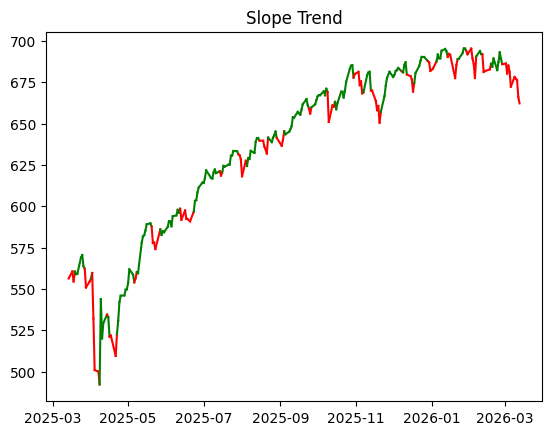

In [94]:
for i in range(1, len(df)):
  c = "g" if df["SlopeTrend"].iloc[i] > 0 else "r"
  plt.plot(
    df.index[i-1:i+1],
    df["Close"].iloc[i-1:i+1],
    color=c
  )

plt.title("Slope Trend")
plt.show()

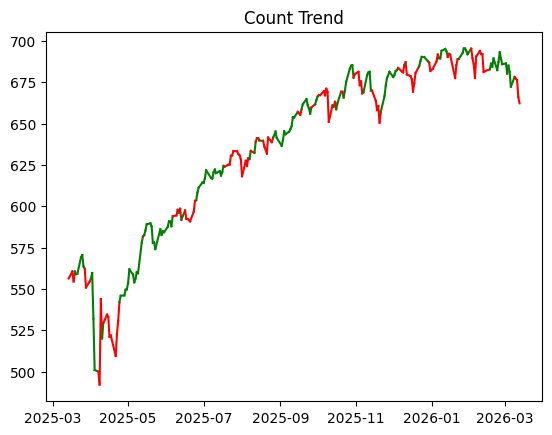

In [95]:
for i in range(1, len(df)):
  c = "g" if df["CountTrend"].iloc[i] > 0 else "r"
  plt.plot(
    df.index[i-1:i+1],
    df["Close"].iloc[i-1:i+1],
    color=c
  )

plt.title("Count Trend")
plt.show()